## 2026-02-08 Mag 7 + Netflix Market Capitalization

In [1]:
%pip install yfinance pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


Fetching data for Alphabet (GOOGL) (GOOGL)...
Fetching data for Amazon (AMZN) (AMZN)...
Fetching data for Apple (AAPL) (AAPL)...
Fetching data for Meta (META) (META)...
Fetching data for Microsoft (MSFT) (MSFT)...
Fetching data for Netflix (NFLX) (NFLX)...
Fetching data for NVIDIA (NVDA) (NVDA)...
Fetching data for Tesla (TSLA) (TSLA)...
Saved figure to mag7_plus_nflx_market_cap_log.png


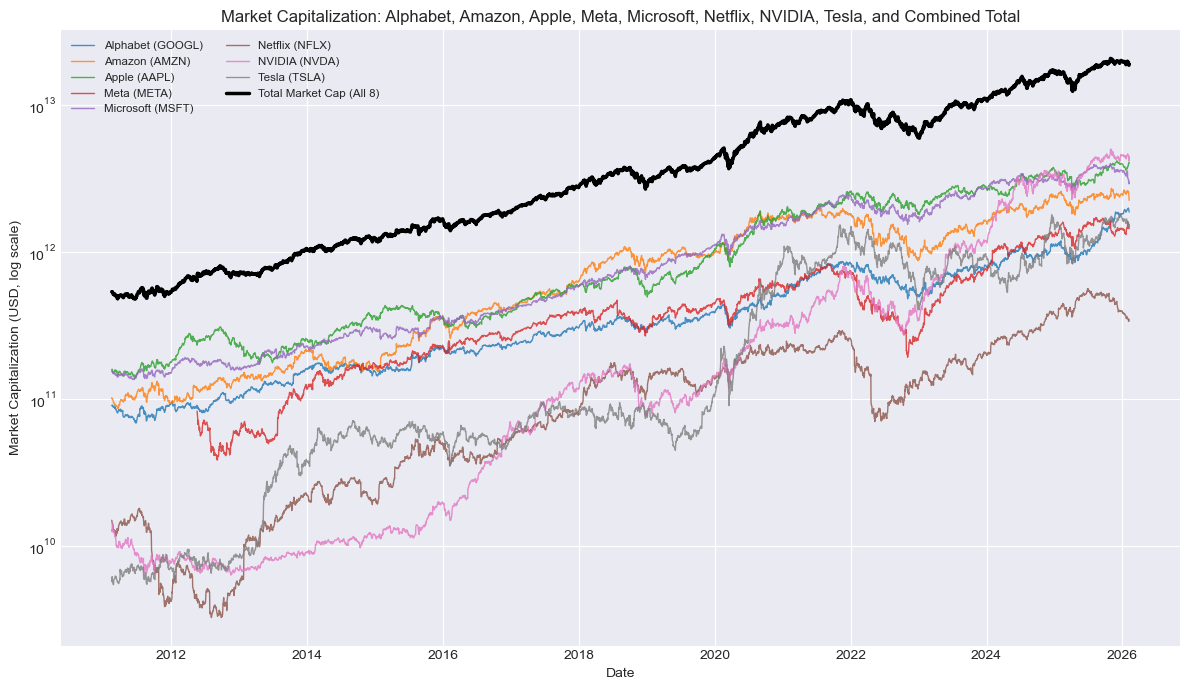

In [3]:
# market_caps_mag7_plus_nflx.py

import datetime as dt

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf


def fetch_market_cap_series(ticker, start, end):
    """
    Fetch daily market cap series for a given ticker between start and end dates.
    Market cap = Adj Close * Shares Outstanding (using latest shares outstanding).
    This approximation is usually good enough for visualization.
    """
    stock = yf.Ticker(ticker)
    hist = stock.history(start=start, end=end, auto_adjust=False)

    if hist.empty:
        raise ValueError(f"No historical data for {ticker}")

    # yfinance exposes shares_outstanding in .info; we use a fixed value over the period
    info = stock.info
    shares_out = info.get("sharesOutstanding", None)
    if shares_out is None:
        raise ValueError(f"No sharesOutstanding field available for {ticker}")

    hist = hist[["Adj Close"]].rename(columns={"Adj Close": "adj_close"})
    hist["market_cap"] = hist["adj_close"] * shares_out
    return hist["market_cap"]


def main():
    # Eight companies: Alphabet (GOOGL), Amazon, Apple, Meta, Microsoft, Netflix, NVIDIA, Tesla
    tickers = {
        "Alphabet (GOOGL)": "GOOGL",
        "Amazon (AMZN)": "AMZN",
        "Apple (AAPL)": "AAPL",
        "Meta (META)": "META",
        "Microsoft (MSFT)": "MSFT",
        "Netflix (NFLX)": "NFLX",
        "NVIDIA (NVDA)": "NVDA",
        "Tesla (TSLA)": "TSLA",
    }

    # Choose a lookback window (e.g. last 15 years)
    end_date = dt.date.today()
    start_date = end_date - dt.timedelta(days=15 * 365)

    all_caps = pd.DataFrame()

    for label, ticker in tickers.items():
        print(f"Fetching data for {label} ({ticker})...")
        mc_series = fetch_market_cap_series(ticker, start_date, end_date)
        mc_series.name = label
        all_caps = pd.concat([all_caps, mc_series], axis=1)

    # Drop rows where everything is NaN (no trading days overlap)
    all_caps = all_caps.dropna(how="all")

    # (2) Combined total market cap across all eight
    all_caps["Total (All 8)"] = all_caps.sum(axis=1, min_count=1)

    # (3) Plot on a log scale
    plt.style.use("seaborn-v0_8-darkgrid")
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot each individual company
    for col in tickers.keys():
        ax.plot(all_caps.index, all_caps[col], linewidth=1.0, alpha=0.8, label=col)

    # Plot the total
    ax.plot(
        all_caps.index,
        all_caps["Total (All 8)"],
        linewidth=2.5,
        color="black",
        label="Total Market Cap (All 8)",
    )

    ax.set_yscale("log")
    ax.set_xlabel("Date")
    ax.set_ylabel("Market Capitalization (USD, log scale)")
    ax.set_title(
        "Market Capitalization: Alphabet, Amazon, Apple, Meta, Microsoft, "
        "Netflix, NVIDIA, Tesla, and Combined Total"
    )

    ax.legend(loc="upper left", fontsize="small", ncol=2)
    fig.tight_layout()

    # Save to file and show
    output_file = "mag7_plus_nflx_market_cap_log.png"
    plt.savefig(output_file, dpi=300)
    print(f"Saved figure to {output_file}")
    plt.show()


if __name__ == "__main__":
    main()